# Adapter Evaluation

Generate lyrics from trained adapters, classify with RoBERTa, and compare against baselines.

In [1]:
import json

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["pdf.fonttype"] = 42

from config import adapter_registry, Adapter, ARTISTS, RESULTS_DIR

# Display-only notebook: it reads cached results, no model is loaded here.
# Generate the cache first with:  uv run python evaluate.py

## Adapter results

Loaded from the cache written by `evaluate.py`. Run `uv run python evaluate.py` first.

In [2]:
# Load per-adapter results cached by evaluate.py (results/adapters/<artist>/<variant>.json).
# Keyed by display label; the Adapter object is re-attached from the registry.
# A STALE notice means the adapter was retrained after its cache was written.
CACHE_DIR = RESULTS_DIR / "adapters"


def _weights_mtime(path):
    return max(f.stat().st_mtime for f in path.rglob("*") if f.is_file())


all_results = {}

for a in adapter_registry():
    cache_file = CACHE_DIR / a.result_relpath
    if not cache_file.exists():
        print(f"skip {a.label}: not evaluated -- run `uv run python evaluate.py`")
        continue

    hit = json.load(open(cache_file))
    if a.path.exists() and hit.get("mtime") != _weights_mtime(a.path):
        print(f"STALE {a.label}: weights newer than cache -- re-run evaluate.py")

    df = pd.DataFrame(hit["df"])
    all_results[a.label] = {"adapter": a, "target": a.artist,
                            "samples": hit["samples"], "df": df}
    print(f"loaded {a.label}: mean {df[a.artist].mean():.4f}")

loaded Gojira LoRA r=8: mean 0.9894
loaded Gojira DoRA r=8: mean 0.9957
loaded Tool LoRA r=8: mean 0.6891
loaded Tool DoRA r=8: mean 0.6311
loaded Death LoRA r=8: mean 0.9025
loaded Death DoRA r=8: mean 0.8826
loaded Mastodon LoRA r=8: mean 0.8733
loaded Mastodon DoRA r=8: mean 0.7022
loaded Opeth LoRA r=8: mean 0.8964
loaded Opeth DoRA r=8: mean 0.9892
loaded Gojira LoRA r=4: mean 0.9945
loaded Gojira LoRA r=16: mean 0.9291
loaded Tool LoRA r=4: mean 0.8378
loaded Tool LoRA r=16: mean 0.7547
loaded Mastodon LoRA r=4: mean 0.9874
loaded Mastodon LoRA r=16: mean 0.8239
loaded Gojira LoRA r=8 SW: mean 0.6737
loaded Tool LoRA r=8 SW: mean 0.9014
loaded Death LoRA r=8 SW: mean 0.9179
loaded Mastodon LoRA r=8 SW: mean 0.8677
loaded Opeth LoRA r=8 SW: mean 0.8504


## Baselines (from 04_baselines.ipynb)

Read from the per-(artist, method) caches in `results/baselines/<artist>/` (written by `04`) so the numbers never drift from a hardcoded copy. Run `04` first.

In [3]:
# Baseline rows from the per-(artist, method) caches written by 04_baselines.
BASELINES_DIR = RESULTS_DIR / "baselines"
_METHOD_LABEL = {"zero_shot": "Zero-shot", "few_shot": "Few-shot",
                 "zero_shot_it": "Zero-shot (it)", "few_shot_it": "Few-shot (it)"}

rows = []
for artist in ARTISTS:
    slug = artist.lower().replace(" ", "_")
    for method, mlabel in _METHOD_LABEL.items():
        cache_file = BASELINES_DIR / slug / f"{method}.json"
        if not cache_file.exists():
            continue
        df = pd.DataFrame(json.load(open(cache_file))["df"])
        rows.append({"Method": f"{artist} {mlabel}", "Artist": artist,
                     "Target Attr. (mean)": df[artist].mean(),
                     "Target Attr. (std)": df[artist].std()})

if not rows:
    print(f"note: no baseline caches in {BASELINES_DIR} -- run 04_baselines first; showing adapters only\n")

for label, data in all_results.items():
    target = data["target"]
    rows.append({"Method": label, "Artist": target,
                 "Target Attr. (mean)": data["df"][target].mean(),
                 "Target Attr. (std)": data["df"][target].std()})

summary = pd.DataFrame(rows)
summary["Target Attr. (mean)"] = summary["Target Attr. (mean)"].round(4)
summary["Target Attr. (std)"] = summary["Target Attr. (std)"].round(4)
print(summary.to_string(index=False))

              Method   Artist  Target Attr. (mean)  Target Attr. (std)
    Gojira Zero-shot   Gojira               0.0017              0.0006
     Gojira Few-shot   Gojira               0.0061              0.0108
      Tool Zero-shot     Tool               0.9927              0.0030
       Tool Few-shot     Tool               0.7846              0.3975
     Death Zero-shot    Death               0.0016              0.0023
      Death Few-shot    Death               0.0016              0.0013
  Mastodon Zero-shot Mastodon               0.0013              0.0003
   Mastodon Few-shot Mastodon               0.0061              0.0108
     Opeth Zero-shot    Opeth               0.0015              0.0004
      Opeth Few-shot    Opeth               0.0035              0.0050
     Gojira LoRA r=8   Gojira               0.9894              0.0195
     Gojira DoRA r=8   Gojira               0.9957              0.0006
       Tool LoRA r=8     Tool               0.6891              0.4343
      

## Plots

/tmp/ipykernel_1348970/2516141710.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  & (~summary["Method"].str.contains(r"r=(4|16)"))].copy()
/tmp/ipykernel_1348970/2516141710.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  & (~summary["Method"].str.contains(r"r=(4|16)"))].copy()
/tmp/ipykernel_1348970/2516141710.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  & (~summary["Method"].str.contains(r"r=(4|16)"))].copy()
/tmp/ipykernel_1348970/2516141710.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  & (~summary["Method"].str.contains(r"r=(4|16)"))].copy()
/tmp/ipykernel_1348970/2516141710.py:14: UserWarning: This pattern i

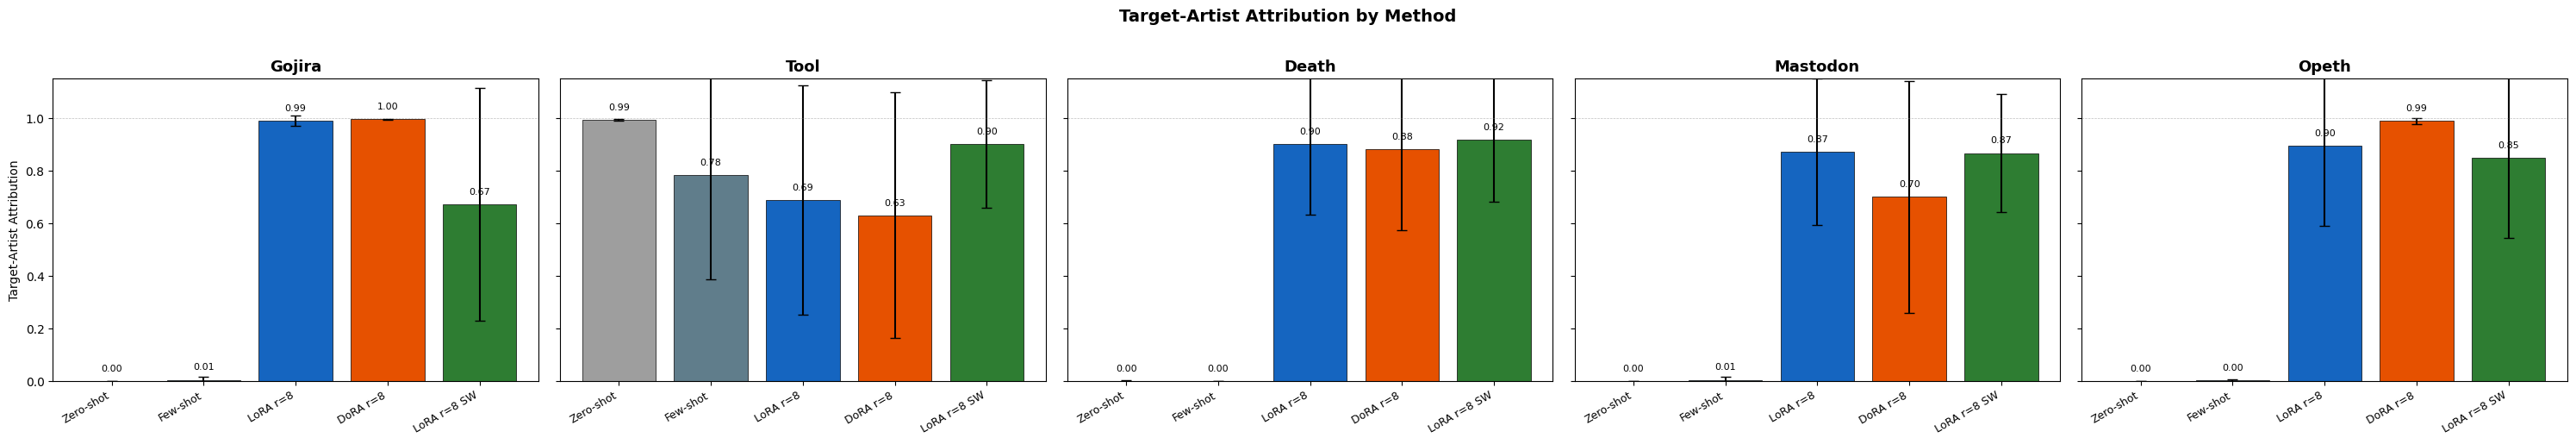

In [4]:
# One panel per artist that appears in the summary (baseline or adapter).
# Instruct baselines (it) are in the summary table + 04, but kept OUT of this
# report figure to avoid crowding -- base baselines + adapters only. Rank
# variants (r=4/16) are likewise excluded here; they live in the ablation figure.
artists_present = [a for a in ARTISTS if (summary["Artist"] == a).any()]
n = len(artists_present)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), sharey=True)
if n == 1:
    axes = [axes]

for ax, artist in zip(axes, artists_present):
    artist_rows = summary[(summary["Artist"] == artist)
                          & (~summary["Method"].str.contains(r"\(it\)"))
                          & (~summary["Method"].str.contains(r"r=(4|16)"))].copy()
    artist_rows["short"] = artist_rows["Method"].str.replace(f"{artist} ", "", regex=False)
    means = artist_rows["Target Attr. (mean)"].values
    stds = artist_rows["Target Attr. (std)"].values
    labels_plot = artist_rows["short"].values
    x = np.arange(len(labels_plot))

    colors = []
    for label in labels_plot:
        if "Zero" in label:
            colors.append("#9e9e9e")
        elif "Few" in label:
            colors.append("#607d8b")
        elif "SW" in label:
            colors.append("#2e7d32")
        elif "DoRA" in label:
            colors.append("#e65100")
        else:
            colors.append("#1565c0")

    bars = ax.bar(x, means, yerr=stds, capsize=4, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels_plot, rotation=30, ha="right", fontsize=9)
    ax.set_title(f"{artist}", fontsize=13, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)

    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
                f"{m:.2f}", ha="center", va="bottom", fontsize=8)

axes[0].set_ylabel("Target-Artist Attribution")
plt.suptitle("Target-Artist Attribution by Method", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../report/figures/method_comparison.pdf", bbox_inches="tight", dpi=300)
plt.show()

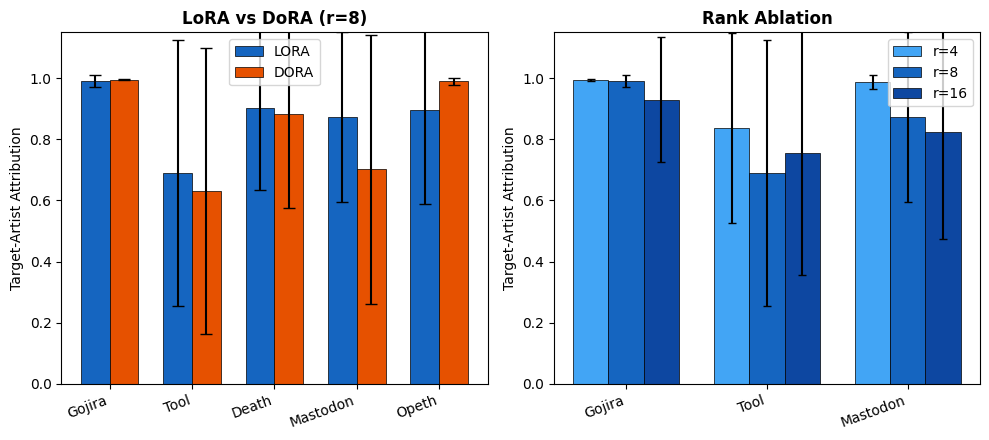

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# LoRA vs DoRA: every artist that has BOTH a lora r8 and dora r8 result.
lora_dora_artists = [
    a for a in ARTISTS
    if Adapter(a, "lora", 8).label in all_results and Adapter(a, "dora", 8).label in all_results
]

ax = axes[0]
x = np.arange(len(lora_dora_artists))
w = 0.35
for i, (kind, color) in enumerate([("lora", "#1565c0"), ("dora", "#e65100")]):
    means, stds = [], []
    for artist in lora_dora_artists:
        d = all_results[Adapter(artist, kind, 8).label]
        means.append(d["df"][d["target"]].mean())
        stds.append(d["df"][d["target"]].std())
    ax.bar(x + i * w, means, w, yerr=stds, capsize=4, label=kind.upper(),
           color=color, edgecolor="black", linewidth=0.5)
ax.set_xticks(x + w / 2)
ax.set_xticklabels(lora_dora_artists, rotation=20, ha="right")
ax.set_ylabel("Target-Artist Attribution")
ax.set_title("LoRA vs DoRA (r=8)", fontweight="bold")
ax.legend()
ax.set_ylim(0, 1.15)

# Rank ablation: every artist with more than just r=8 evaluated (currently
# Gojira/Tool/Mastodon -- hypothesis-picked, see adapter_registry docstring).
ax = axes[1]
rank_artists = [a for a in ARTISTS
                if sum(Adapter(a, "lora", r).label in all_results for r in (4, 8, 16)) >= 2]
x = np.arange(len(rank_artists))
w = 0.25
for i, (r, color) in enumerate(zip((4, 8, 16), ("#42a5f5", "#1565c0", "#0d47a1"))):
    means, stds = [], []
    for artist in rank_artists:
        d = all_results.get(Adapter(artist, "lora", r).label)
        means.append(d["df"][d["target"]].mean() if d else np.nan)
        stds.append(d["df"][d["target"]].std() if d else 0)
    ax.bar(x + i * w, means, w, yerr=stds, capsize=3, label=f"r={r}",
           color=color, edgecolor="black", linewidth=0.5)
ax.set_xticks(x + w)
ax.set_xticklabels(rank_artists, rotation=20, ha="right")
ax.set_ylabel("Target-Artist Attribution")
ax.set_title("Rank Ablation", fontweight="bold")
ax.legend()
ax.set_ylim(0, 1.15)

plt.tight_layout()
plt.savefig("../report/figures/ablation.pdf", bbox_inches="tight", dpi=300)
plt.show()

## Sample Lyrics

Best sample per adapter (highest target-artist attribution).

In [7]:
for name, data in all_results.items():
    target = data["target"]
    best_idx = data["df"][target].idxmax()
    score = data["df"].loc[best_idx, target]
    text = data["samples"][best_idx]
    print(f"{'='*60}")
    print(f"{name} — best sample (attribution: {score:.3f})")
    print(f"{'='*60}")
    print(text[:800])
    print("...\n" if len(text) > 800 else "\n")

Gojira LoRA r=8 — best sample (attribution: 0.996)
I am not able to understand what is happening to me
This world has become a cage for me and I'm lost in the maze


All around, you will see this giant bird of prey
Rising on the wind to the skies
Flying through the air, flying at speed of light
Out there it goes leaving behind the dust
And all around, the great circle is so clear
It flies across vast ocean planes
The eagles are laughing in their nests up there
At the sight of this huge creature


I want to believe that I can fly
Soar high and away


Take off from where you are right now
Into the open sky
Now free yourself from chains of life
Open your mind and embrace the silence
Of space and time, no force upon you now
No gravity, no rules


Fly in the wild
You don't have to be told how to live anymore
Inexorable laws do not apply to you

...

Gojira DoRA r=8 — best sample (attribution: 0.996)
It's a long way down
And it ain't easy to get up
You have the strength to last
You're not al